# Amplitude modulated low frequency noise drive qubit simulation

### Author: Daniel Gonçalves Benvenutti - UNICAMP
28 May 2025

Qutip Version: 5.1.1

This notebook is more succint because it's easier to see the effects of the low frequecy noises (brown and pink) modulated by the qubit resonance frequency as carrier wave. This scenarion could happen in a real experiment if in the circuit of excitation there's some non linearity that mixes/multiplies the low frequency noise to the drive signal. 

The signals would be summed togheter in the cables initially, $V_d(t)+\xi(t)$ where $V_d(t)$ is the drive and $\xi(t)$ is the noise. Then when they go through some nonlinear component for example a diode that has an exponential transfer function:

$$v_{out}(t)=e^{v_{in}(t)}=1+V_{in}(t)+\frac{V_{in}(t)^2}{2}+O(V_{in}(t)^3)$$

Our output would be then:

$$ v_{out}(t)=1+V_d(t)+\xi(t)+\frac{{V_d(t)+\xi(t)}^2}{2}+O(V_{in}(t)^3) =1+V_d(t)+\xi(t)+\frac{V_d(t)^2}{2}+\frac{\xi(t)^2}{2}+\mathbf{V_d(t)\xi(t)}+O(V_{in}(t)^3) $$

The term that matters is $V_d(t)\xi(t)$ because by multiplying both signals we are doing the same as a amplitude modulation and dislocating the spectrum of the noise $\xi(t)$  with it's mirrored version to the position of our $V_d(t)$ since it's a pure sine wave. This doesn't matter for white noise since it covers all the spectrum and dislocating it just generates a different white noise. But for pink and brown noise or low frequency noises if this process happens the majority of the noise will be close to the qubit resonance where it has the largest effect on the qubit.

Pink noise is more evenly distributed than brown noise because it has a $\frac{1}{\sqrt{f}}$ decay on the spectrum, so we see with it more of a random walk like curve if we apply just this modulated pink noise without the carrier (the sine drive signal), though we need much less amplitude to see a very significant effect than using pure white noise.

Amplitude modulated brown noise can look like a pure excitation signal without the carrier and it has a very smoother qubit evolution curve. Here we are basically modulating a pure drive signal's amplitude with a random walk, so we see a period varying Rabi oscillation for this case.

If we mix up both of these noises with the main carrier drive signal we need the noise signal to be half of our drive signal to see an effect and it looks like some sort of random frequency modulation on the Rabi oscillation frequency.



In [129]:
# to use in google colab
!pip install qutip

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [130]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.graphics.tsaplots import plot_acf

## Simulation Parameters



In [131]:
# parameters
wq=3*2*np.pi #qubit resonance frequency [GHz.rad]
Ed=0.01*2*np.pi #driving energy [GHz.rad]

pi_pulse=np.pi/Ed #[ns]
print(f"pi pulse={pi_pulse:.2e}")

T1=2000 #relaxation time [ns]
T2=1000 #dephasing time [ns]

# (T2 must be T2<=2T1)
if T2>2*T1:
  raise Exception("T2 must be T2<=2T1")

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

# hamiltonian
def H(wq, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  if Ed_t is None:
    return -0.5*wq*sz/wq
  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]],tlist=tlist*wq)

# colapse operators normalized by wq
def c_ops(T1, T2): #T1[ns], T2[ns]
  if T2 is None:
    return [np.sqrt(1/T1/wq)*sm]
  gamma_phi=1/T2-1/2/T1 #pure dephasing constant
  return [np.sqrt(1/T1/wq)*sm,np.sqrt(gamma_phi/2/wq)*sz]
  #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms



pi pulse=5.00e+01


In [132]:
def plot_tomography(res):
  fig, axes = plt.subplots(3, 1, figsize=(8, 10))  # Adjust figure size as needed

  # Plot sx
  axes[0].plot(t, res.expect[0])
  axes[0].set_xlabel('Time (ns)')
  axes[0].set_ylabel('<σx>')
  axes[0].set_title('Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  axes[1].plot(t, res.expect[1])
  axes[1].set_xlabel('Time (ns)')
  axes[1].set_ylabel('<σy>')
  axes[1].set_title('Expectation Value of $\sigma_y$')

  # Plot sz
  axes[2].plot(t, res.expect[2])
  axes[2].set_xlabel('Time (ns)')
  axes[2].set_ylabel('<σz>')
  axes[2].set_title('Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

In [133]:
def noise_psd(tlist, psd = lambda f: 1):
    N=len(tlist)
    X_white = np.fft.rfft(np.random.randn(N));
    S = psd( np.fft.rfftfreq(N, d=tlist[1]-tlist[0]) )
    # Normalize S
    S = S / np.sqrt(np.mean(S**2))
    X_shaped = X_white * S;
    return np.fft.irfft(X_shaped, n=N);

def PSDGenerator(f):
    return lambda N: noise_psd(N, f)

@PSDGenerator
def white_noise(f):
    return 1;

@PSDGenerator
def blue_noise(f):
    return np.sqrt(f);

@PSDGenerator
def violet_noise(f):
    return f;

@PSDGenerator
def brownian_noise(f):
    return 1/np.where(f == 0, float('inf'), f)

@PSDGenerator
def pink_noise(f):
    return 1/np.where(f == 0, float('inf'), np.sqrt(f))

# Noise only

## Amplitude modulated pink noise

In [134]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t: Ed*(np.sin(wd*t))
drive_data=pure_drive(tlist)*pink_noise(tlist)

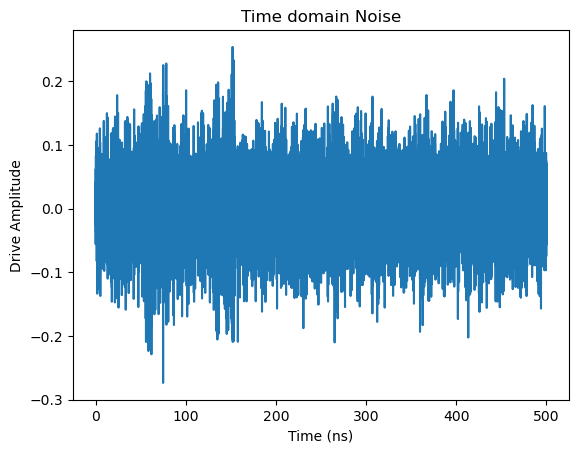

In [135]:
# Define the start and end indices for the portion you want to plot


# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist, drive_data)
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Time domain Noise')
plt.show()

39789


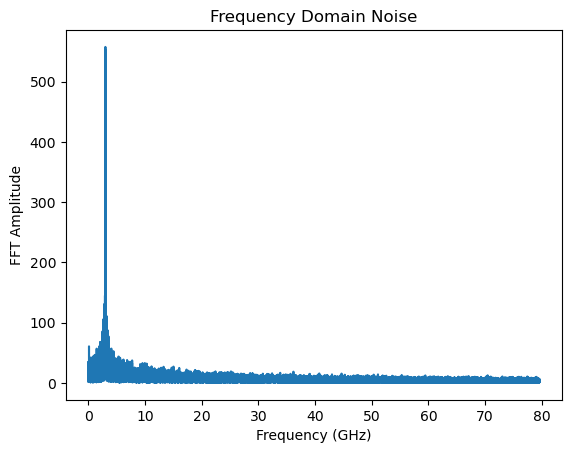

In [136]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])

middle=len(freq)//2
print(middle)
# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.abs(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('Frequency Domain Noise')
plt.show()

In [137]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,e_ops=[sx, sy, sz],options=dict(nsteps=5000))

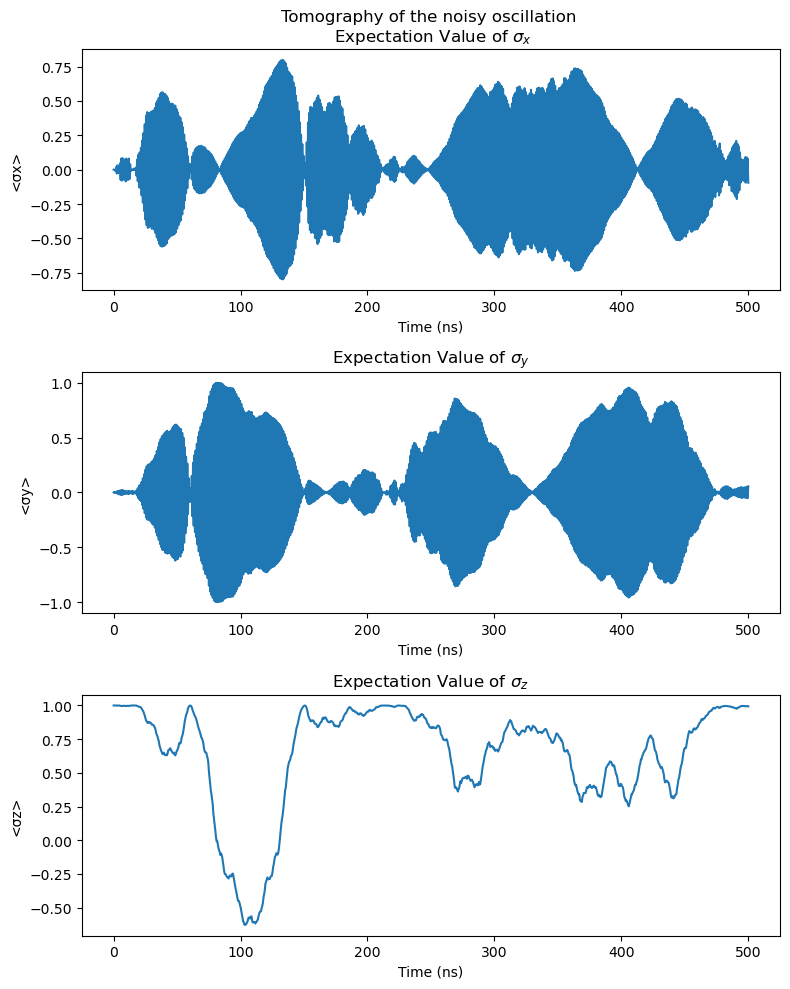

In [138]:
# prompt: Generate a plot of the three expectation values sx, sy, sz from res expect using t as x axis in different subplots

plot_tomography(res)

## Amplitude modulated brown noise

In [139]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,500,int(500*3000/wq)+1) # ns
pure_drive=lambda t: Ed*(np.sin(wd*t))
drive_data=pure_drive(tlist)*brownian_noise(tlist)

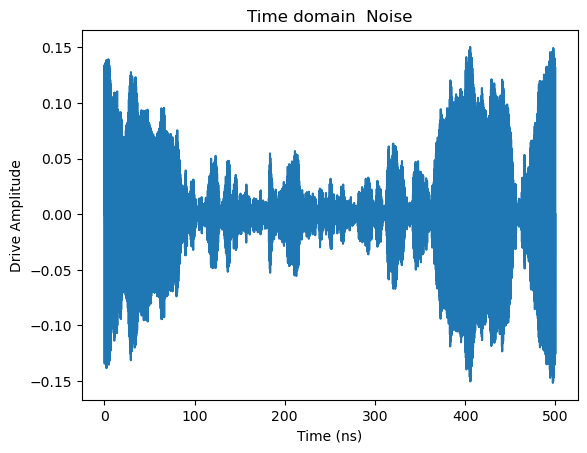

In [140]:
# Define the start and end indices for the portion you want to plot


# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist, drive_data)
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Time domain  Noise')
plt.show()

39789


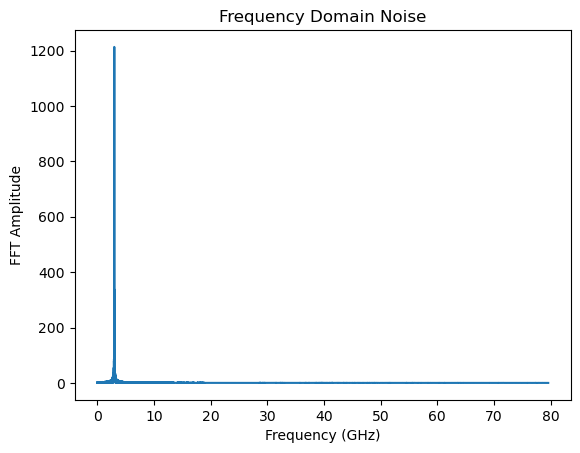

In [141]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])

middle=len(freq)//2
print(middle)
# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.abs(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('Frequency Domain Noise')
plt.show()

In [142]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,500,1000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,e_ops=[sx, sy, sz],options=dict(nsteps=5000))

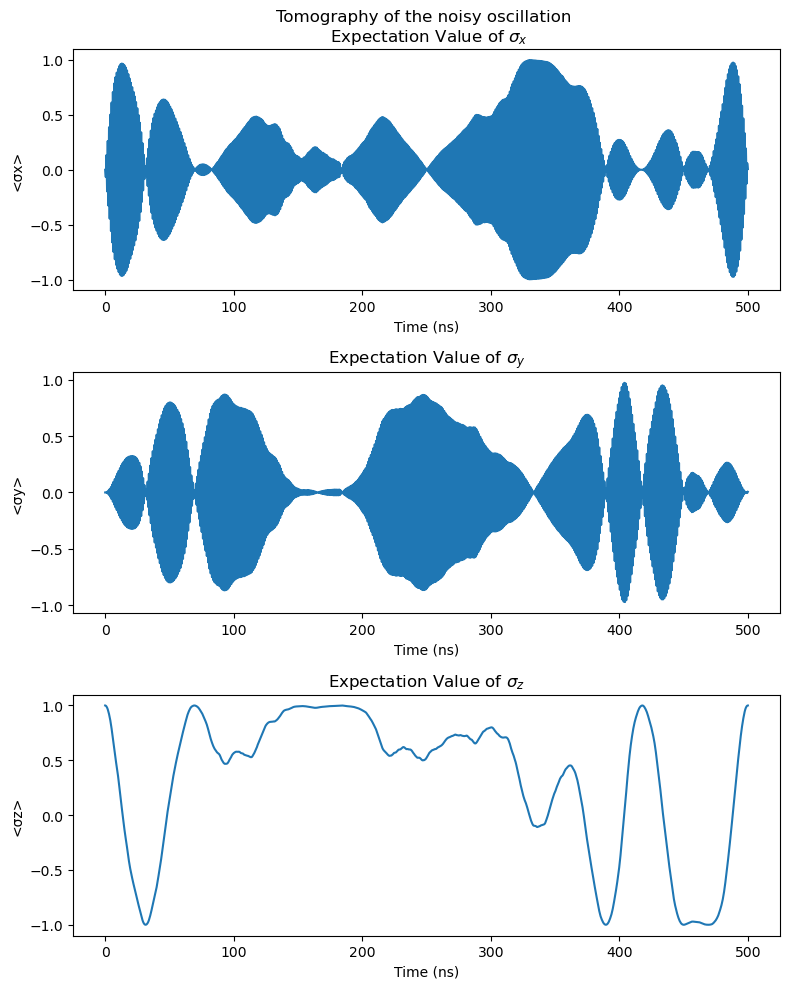

In [143]:
# prompt: Generate a plot of the three expectation values sx, sy, sz from res expect using t as x axis in different subplots

plot_tomography(res)

# Noise and drive

## Amplitude modulated pink noise

In [144]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,1000,int(500*3000/wq)+1) # ns
pure_drive=lambda t: Ed*(np.sin(wd*t))
drive_data=pure_drive(tlist)+0.5*pure_drive(tlist)*pink_noise(tlist)

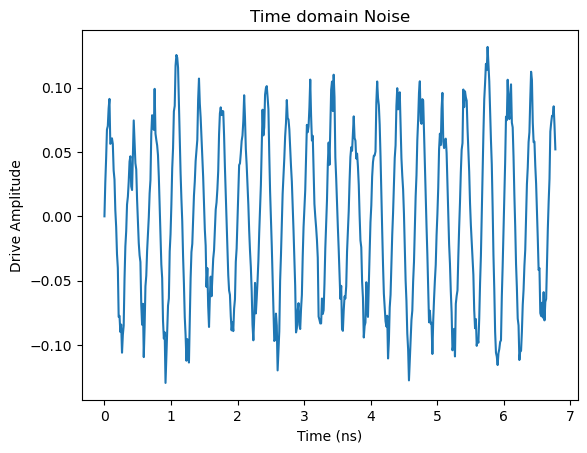

In [145]:
# Define the start and end indices for the portion you want to plot

start_index = 0
end_index = int(64/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Time domain Noise')
plt.show()

39789


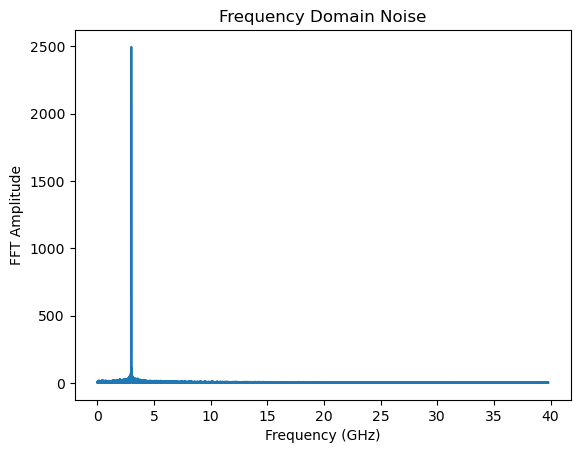

In [146]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])

middle=len(freq)//2
print(middle)
# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.abs(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('Frequency Domain Noise')
plt.show()

In [147]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,1000,2000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,e_ops=[sx, sy, sz],options=dict(nsteps=5000))

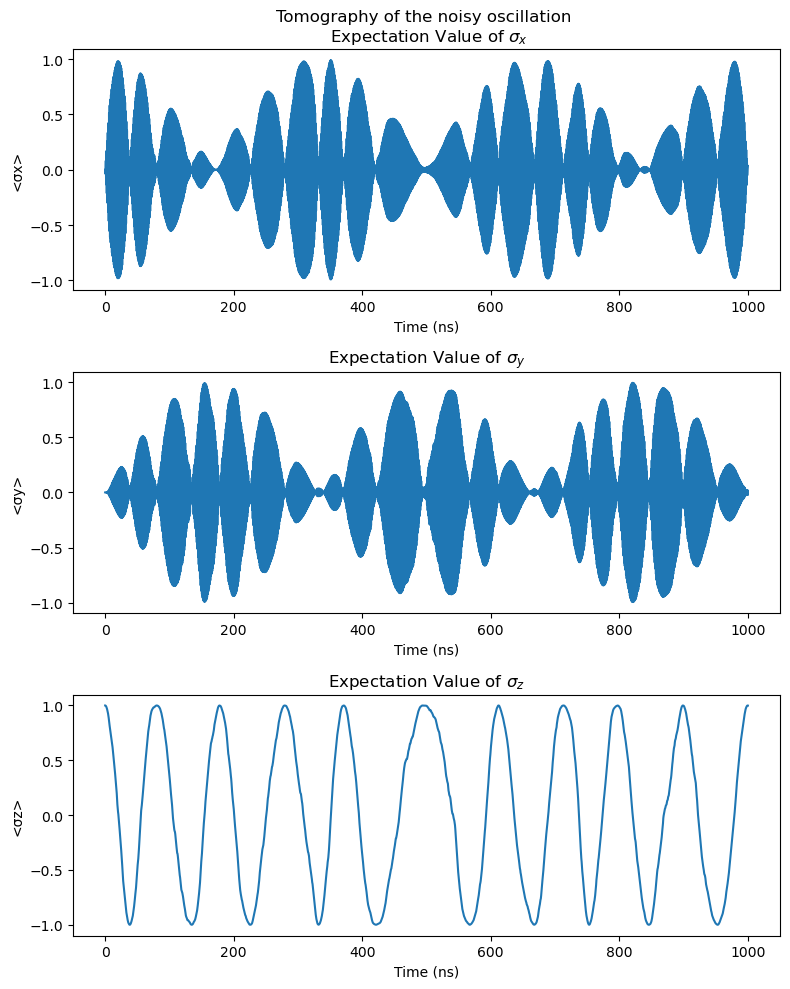

In [148]:
# prompt: Generate a plot of the three expectation values sx, sy, sz from res expect using t as x axis in different subplots

plot_tomography(res)

## Amplitude modulated brown noise

In [149]:
#signal parameters
Det=0 # [GHz]
wd=wq+Det*2*np.pi # [rad.GHz]
tlist=np.linspace(0,1000,int(500*3000/wq)+1) # ns
pure_drive=lambda t: Ed*(np.sin(wd*t))
drive_data=pure_drive(tlist)+0.5*pure_drive(tlist)*brownian_noise(tlist)

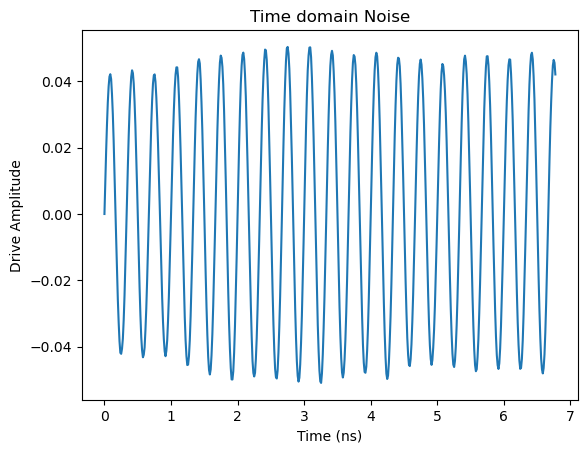

In [150]:
# Define the start and end indices for the portion you want to plot

start_index = 0
end_index = int(64/wq/500*len(tlist))  # Adjust as needed

# Create the plot for a specific range of 'tlist' and 'drive_data'
plt.plot(tlist[start_index:end_index], drive_data[start_index:end_index])
plt.xlabel('Time (ns)')
plt.ylabel('Drive Amplitude')
plt.title('Time domain Noise')
plt.show()

39789


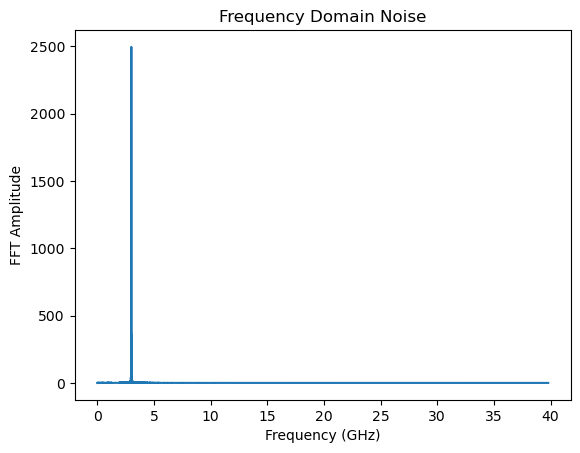

In [151]:
# prompt: plot the fft of drive_data with a proper freq axis

# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])

middle=len(freq)//2
print(middle)
# Plot the FFT with proper frequency axis
plt.plot(freq[:middle], np.abs(drive_fft)[:middle])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('Frequency Domain Noise')
plt.show()

In [152]:
# initial state
psi0=qtp.basis(2,0)
t=np.linspace(0,1000,2000) #ns
res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,e_ops=[sx, sy, sz],options=dict(nsteps=5000))

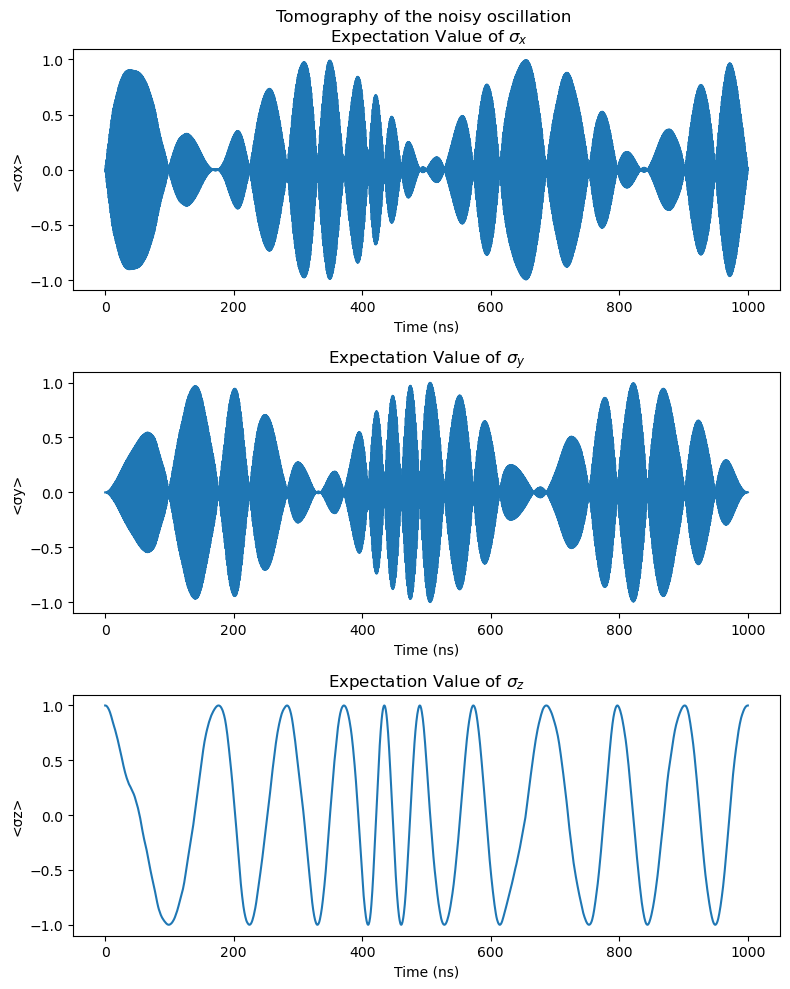

In [153]:
# prompt: Generate a plot of the three expectation values sx, sy, sz from res expect using t as x axis in different subplots

plot_tomography(res)